# Importing Libraries

In [3]:
%load_ext autoreload
%autoreload 2


import sys
from pathlib import Path
cataFolder = Path(r"Z:\RawData\TestCata")
sys.path.append(str(cataFolder))  # Add the folder to Python path
#from sampleDictFile import sampleDict
from VECTORtools import *

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore') #deactivates all warnings

ModuleNotFoundError: No module named 'VECTORtools'

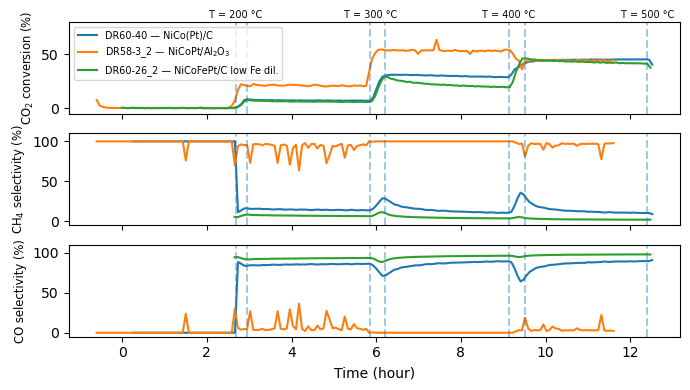

In [21]:
samples = ['DR60-40', 'DR58-3_2', 'DR60-38_2', 'DR60-26_2']
samples = ['DR60-40', 'DR58-3_2',  'DR60-26_2']

triPlot(samples)

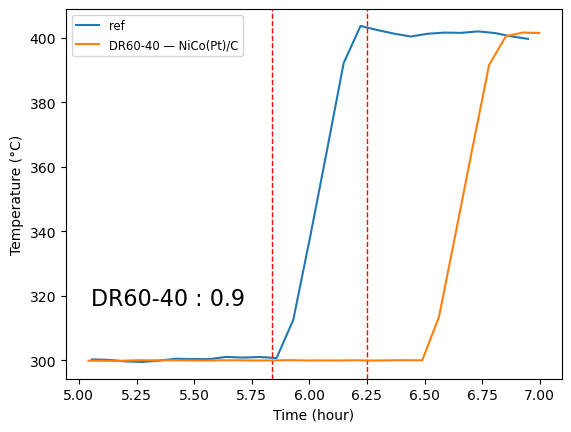

In [25]:
sample = 'DR60-40'

tweakTimeOffset(sample, 0.9)

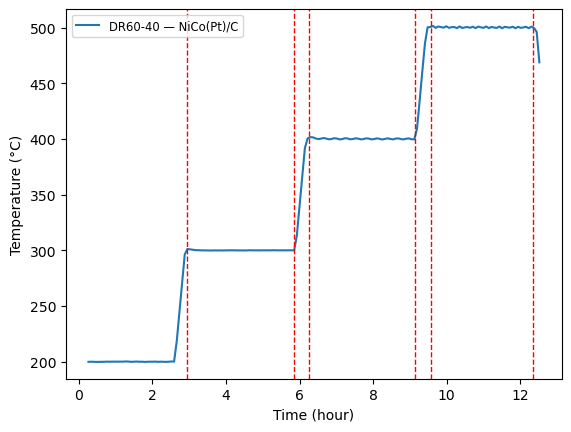

In [9]:
%matplotlib inline
plt.close()
samples = ['DR60-40']

tempPlot(samples)




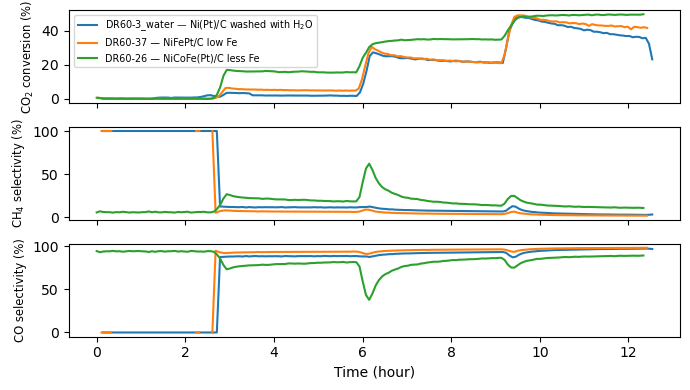

In [340]:
#samples = ['DR60-26', 'DR60-26_5']
samples = ['DR60-3_water', 'DR60-37', 'DR60-26']
#samples = ['DR60-38_2', 'DR60-26_2']


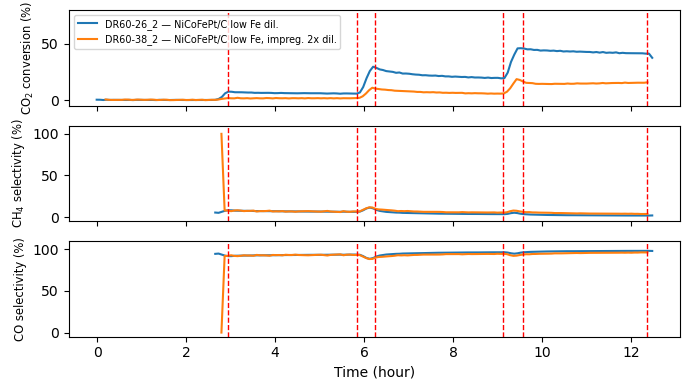

In [55]:
#samples = ['DR60-26', 'DR60-26_5']
samples = ['DR60-26_2', 'DR60-38_2']
#samples = ['DR60-38_2', 'DR60-26_2']



triPlot(samples, vlines = True)

In [ ]:
plt.close()

samples = ['DR60-26_2', 'DR60-25_2', 'DR60-26', 'DR60-25']

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(7, 4))

for sample in samples:
    df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]]
    df.index = df.index - df.index[0]
    df, _ = calcConv(df)
    df, C_CO2_max, normFact = calcSelect(df)
    axs[0].plot(df['Conversion'], label = sampleDict[sample]['label'])
    axs[1].plot(df['S_CH4']*100)
    axs[2].plot(df['S_CO']*100)
    

axs[0].set_ylabel('CO$_2$ conversion (%)', fontsize='small')
axs[0].legend(fontsize='x-small')

axs[1].set_ylabel('CH$_4$ selectivity (%)', fontsize='small')

axs[2].set_ylabel('CO selectivity (%)', fontsize='small')
axs[2].set_xlabel('Time (hour)')
plt.tight_layout()

# Plotting OPC, GC, GDS data over time

In [299]:
# Load the files
sample = 'DR60-38_2'
df = mergeOnGDS(cataFolder, sampleDict[sample])

%matplotlib qt
#plot in new window
#plt.close() #closes previous plots
fig, axs = plt.subplots(3, 1, sharex=True) #this plots the three plots together, with shared x axis!! 

df['Temperature'].plot(ax=axs[0])
ax0_twin = axs[0].twinx() #second y axis for power output
df['POutput'].plot(ax=ax0_twin, alpha=0.3, color='red') #alpha is just for colour shade, semi-transparent
ax0_twin.set_ylabel('Power output (%)', color='red')
ax0_twin.tick_params(axis='y', labelcolor='red')
ax0_twin.legend(fontsize='small', loc='upper right')
axs[0].legend(fontsize='small', loc='upper left')
axs[0].set_ylabel('Temperature (°C)')
axs[0].set_title(sampleDict[sample]['label'])

df['C_H2'].plot(ax=axs[1])
df['C_CO2'].plot(ax=axs[1])
#df['NC_N2'].plot(ax=axs[1])
df['C_CH4'].plot(ax=axs[1])
df['C_CO'].plot(ax=axs[1])
axs[1].legend(fontsize='small')
axs[1].set_ylabel('Compound Concentration (% mol)')

df['H2'].plot(ax=axs[2])
df['CO2'].plot(ax=axs[2])
df['N2'].plot(ax=axs[2])
ax2_twin = axs[2].twinx()
#df['React_Pressure'].plot(ax=ax2_twin, alpha=0.3, color='red')
#ax2_twin.set_ylabel('Reactor Pressure (bar)', color='red')
df['BFC_Pressure'].plot(ax=ax2_twin, alpha=0.3, color='red')
ax2_twin.set_ylabel('BFC Pressure (bar)', color='red')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2_twin.legend(fontsize='small', loc='upper right')
axs[2].legend(fontsize='small', loc='upper left')
axs[2].set_ylabel('Flow (ml/min)')

axs[2].set_xlabel('Time (h)')
plt.tight_layout()

# Display the plot
#plt.xlabel('Time (h)')
#plt.savefig('{}_plot.pdf'.format(sample), format='pdf')
#plt.show()

# Plotting Temperature and CO$_2$ conversion over time - 1 sample

Text(0.5, 1.0, 'DR60-38_2 — NiCoFePt/C low Fe, impreg. 2x dil.')

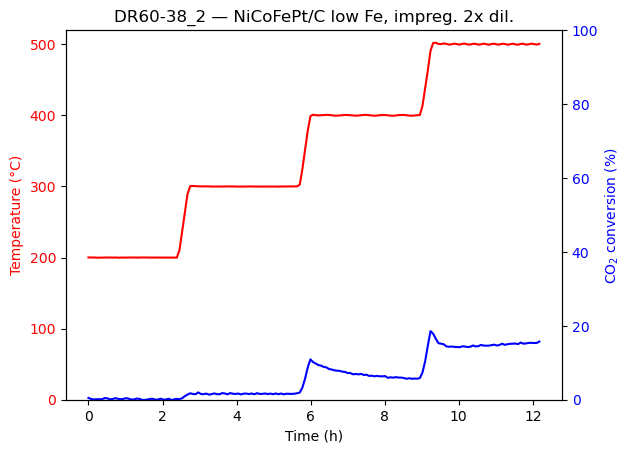

In [22]:
plt.close()

sample = 'DR60-38_2'
%matplotlib inline

df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]] #this range makes it plot only relevant data
df.index = df.index - df.index[0] #time adjustment
df, _ = calcConv(df)

fig, ax1 = plt.subplots()
ax1.plot(df['Temperature'], color='red')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Temperature (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(0, 520)

ax2 = ax1.twinx()
ax2.plot(df['Conversion'], color='blue')
ax2.set_ylabel('CO$_2$ conversion (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 100)

plt.title(sampleDict[sample]['label'])

# Plotting CO$_2$ conversion over time - multiple samples

15.428768538888887
15.45849357
15.350450709999999
15.145056226666668


Text(0, 0.5, 'CO$_2$ conversion (%)')

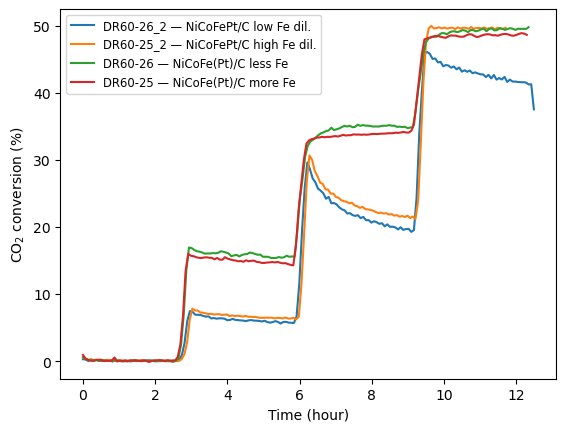

In [47]:
plt.close()
%matplotlib inline

samples = samples = ['DR60-26_2', 'DR60-25_2', 'DR60-26', 'DR60-25']
for sample in samples:
    df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]]
    df.index = df.index - df.index[0]
    df, _ = calcConv(df)
    plt.plot(df['Conversion'], label = sampleDict[sample]['label'])

plt.legend(fontsize='small')
plt.xlabel('Time (hour)')
plt.ylabel('CO$_2$ conversion (%)')

# Plotting CO$_2$ conversion over Temperature - Multiple samples

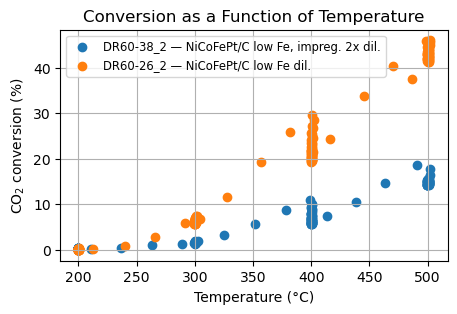

In [32]:
#plt.close()
%matplotlib inline
samples = ['DR60-38_2', 'DR60-26_2']
plt.figure(figsize=(5, 3))

for sample in samples:
    df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]]
    df, _ = calcConv(df)
    plt.scatter(df['Temperature'], df['Conversion'], alpha=1, label = sampleDict[sample]['label'])

plt.xlabel('Temperature (°C)')
plt.ylabel('CO$_2$ conversion (%)')
plt.title('Conversion as a Function of Temperature')
#plt.legend(fontsize=45)
plt.xticks()
plt.yticks()
plt.legend(fontsize='small')
plt.grid(True)
plt.show()
#plt.savefig('SIXS_ConvPlot.pdf'.format(sample), format='pdf')

# Plotting CH$_4$ and CO selectivity over time - Multiple samples

15.428768538888887
15.45849357
15.350450709999999
15.145056226666668


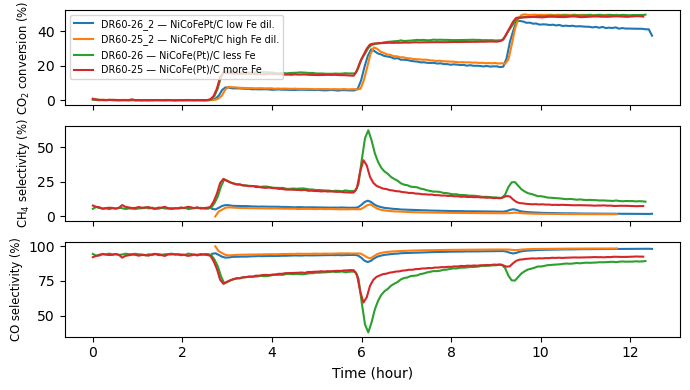

In [43]:
plt.close()
%matplotlib inline
samples = ['DR60-26_2', 'DR60-25_2', 'DR60-26', 'DR60-25']

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(7, 4))

for sample in samples:
    df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]]
    df.index = df.index - df.index[0]
    df, _ = calcConv(df)
    df, C_CO2_max, normFact = calcSelect(df)
    axs[0].plot(df['Conversion'], label = sampleDict[sample]['label'])
    axs[1].plot(df['S_CH4']*100)
    axs[2].plot(df['S_CO']*100)
    

axs[0].set_ylabel('CO$_2$ conversion (%)', fontsize='small')
axs[0].legend(fontsize='x-small')

axs[1].set_ylabel('CH$_4$ selectivity (%)', fontsize='small')

axs[2].set_ylabel('CO selectivity (%)', fontsize='small')
axs[2].set_xlabel('Time (hour)')
plt.tight_layout()
#plt.savefig('SIXS_selectPlot.pdf'.format(sample), format='pdf')

# Plotting CH$_4$ and CO concentrations over Temperature - Multiple samples

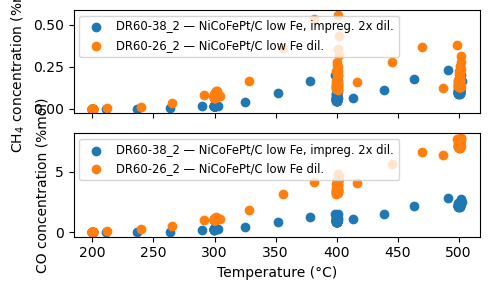

In [38]:
plt.close()
%matplotlib inline
samples = ['DR60-38_2', 'DR60-26_2']

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(5, 3))

for sample in samples:
    df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]]
    df.index = df.index - df.index[0]
    axs[0].scatter(df['Temperature'] , df['C_CH4'], alpha=1, label = sampleDict[sample]['label'])
    axs[1].scatter(df['Temperature'], df['C_CO'], alpha=1, label = sampleDict[sample]['label'])


axs[0].legend(fontsize='small')
axs[0].set_ylabel('CH$_4$ concentration (%mol)')


axs[1].legend(fontsize='small')
axs[1].set_ylabel('CO concentration (%mol)')
axs[1].set_xlabel('Temperature (°C)')
plt.tight_layout()
#plt.savefig('SIXS_selectPlot.pdf'.format(sample), format='pdf')

# Plotting CH$_4$ and CO selectivities over temperature - Multiple samples

In [14]:
#with respect to CH4 and CO

samples = ['DR60-38_2', 'DR60-26_2']

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(5, 3))

for sample in samples:
    df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]]
    df, _ = calcConv(df)
    df.index = df.index - df.index[0]
    axs[0].scatter(df['Temperature'], 100 * df['C_CH4'] / (df['C_CH4'] + df['C_CO']), alpha=1, label = sampleDict[sample]['label'])
    axs[1].scatter(df['Temperature'], 100 * df['C_CO'] / (df['C_CH4'] + df['C_CO']), alpha=1, label = sampleDict[sample]['label'])
    # axs[0].scatter(df.index, 100 * df['C_CH4'] / (df['C_CH4'] + df['C_CO']), alpha=1, label = sampleDict[sample]['label'])
    # axs[1].scatter(df.index, 100 * df['C_CO'] / (df['C_CH4'] + df['C_CO']), alpha=1, label = sampleDict[sample]['label'])


axs[0].legend(fontsize='small')
axs[0].set_ylabel('CH$_4$ selectivity (% mol)', fontsize=18)


axs[1].legend(fontsize='small')
axs[1].set_ylabel('CO selectivity (% mol)', fontsize=18)
axs[1].set_xlabel('Temperature (°C)', fontsize=18)
axs[0].set_ylim(-5, 110)
axs[1].set_ylim(-5, 110)
plt.tight_layout()
plt.savefig('SIXS_selectPlot.pdf'.format(sample), format='pdf')

# Carbon Balance

In [10]:
# Carbon balance

sample = 'DR60-38_2'
%matplotlib qt

df = mergeOnGC(sample).iloc[
    sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]
]
df.index = df.index - df.index[0]
df, _ = calcConv(df)

CO2_in = df['C_CO2'].max()

# Carbon balance (%)
carbon_balance = CO2_in - df['C_CO2'] - df['C_CH4'] - df['C_CO']

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# Top panel: Gas concentrations

ax1.plot(df['Temperature'], df['C_CO2'],
         color='forestgreen', lw=2, label='CO$_2$')

ax1.plot(df['Temperature'], df['C_CO'],
         color='darkorange', lw=2, label='CO')

ax1.plot(df['Temperature'], df['C_CH4'],
         color='royalblue', lw=2, label='CH$_4$')

ax1.set_ylabel('Concentration (%mol)')
ax1.legend()
ax1.grid(alpha=0.3)

# Bottom panel: Carbon balance

ax2.plot(df['Temperature'],
         carbon_balance,
         color='red',
         lw=2,
         label = r'$CO_{2,\mathrm{in}} = CO_{2,\mathrm{out}} + CH_{4,\mathrm{out}} + CO_{\mathrm{out}}$')

ax2.axhline(0,
            color='k',
            linestyle='--',
            lw=1)

ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Balance (%mol)')
ax2.legend()
ax2.set_ylim(-10, 5)
ax2.grid(alpha=0.3)

fig.suptitle(sampleDict[sample]['label'])
plt.tight_layout()

In [62]:
#quantitative analysis of gain/loss of activity and selectivity

# sample = 'DR60-26_3'

# df = mergeOnGC(sample).iloc[sampleDict[sample]['TPrange'][0]:sampleDict[sample]['TPrange'][1]]
# df, _ = calcConv(df)
# df.index = df.index - df.index[0]

# df.head()